In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt
# %matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [ ]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the four classes:
# white tarp, black tarp, aspen, conifer

# update from 7/28/25: MUCH broader LUT re: h20str, aod550 values. h20str - 0.0001-2. Lowering the lower bound of h20str from 1 to 0.0001 is what made the big difference. Upper value change did nothing.
# then also changed the aod550 values to go higher (up to 3 from 0.5, mainly just to check but also because it got pretty smokey sometimes). 

In [2]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
cal = home+'test_roi/calTarp/'

rtes = ['sRTMnet']

dir_insitu = home+'insitu/'

In [3]:
## define cal tarp roi

bboxes = {}
bboxes['WhiteTarp'] = [17,24,23,30]
bboxes['BlackTarp'] = [7,23,12,29]
bboxes

{'WhiteTarp': [17, 24, 23, 30], 'BlackTarp': [7, 23, 12, 29]}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07828101..2.0].


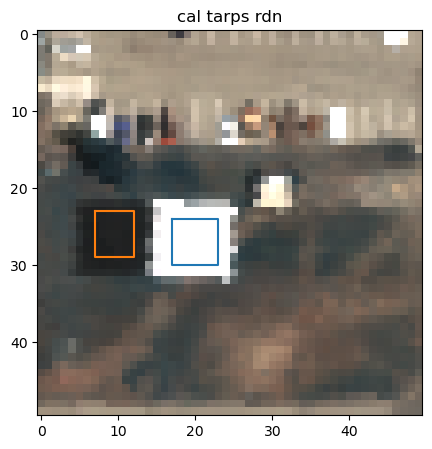

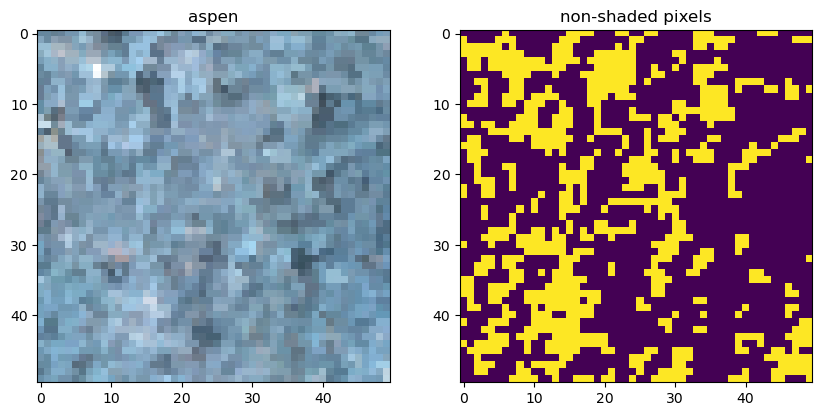

In [4]:
# visualize full rdn w regions averaged to single pixels

# cal tarps
fig = plt.figure(figsize=(10,5))
fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
plt.imshow(rgb / np.max(rgb, axis=(0, 1))*2)
for k, (minx, miny, maxx, maxy) in bboxes.items():
    x = [minx, maxx, maxx, minx, minx]
    y = [miny, miny, maxy, maxy, miny]
    plt.plot(x, y, label=k)
plt.title('cal tarps rdn')
plt.show()

# aspen
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
fp = glob(os.path.join(home, 'test_roi', 'aspen', 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[0].set_title('aspen')
lit = np.sum(rgb, axis=2)
valid = lit > 5
axs[1].imshow(valid)
axs[1].set_title('non-shaded pixels')
plt.show()

In [5]:
# prepare representative single pixels

rdn = {}
obs = {}
loc = {}
for k in bboxes.keys():
    minx, miny, maxx, maxy = bboxes[k]
    fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
    rdn[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_obs.hdr'))[0]
    obs[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_igm.hdr'))[0]
    loc[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
for veg in ['aspen', 'conifer']:
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn.hdr'))[0]
    tmp = envi.open(fp).open_memmap(interleave='bip').copy()
    shaded = np.sum(tmp[...,[60,40,30]], axis=2) < 5
    tmp[shaded, :] = np.nan
    rdn[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_obs.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    obs[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_igm.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    loc[veg] = np.nanmean(tmp, axis=(0,1))

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 

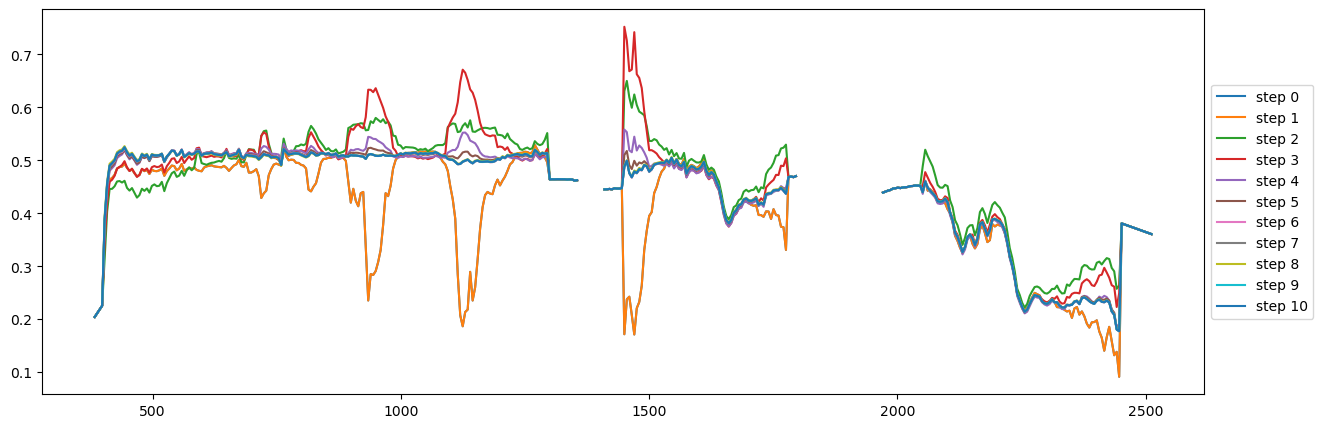

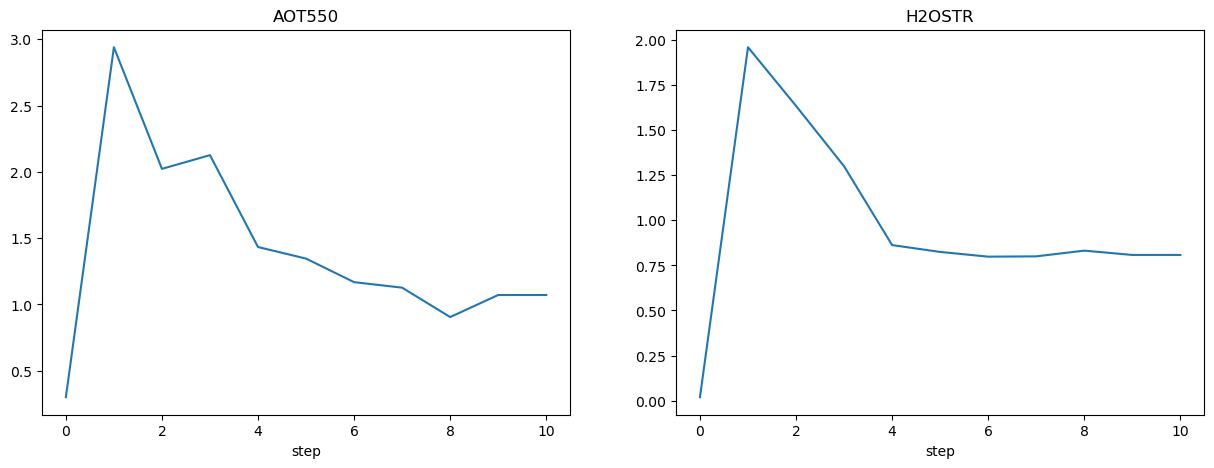

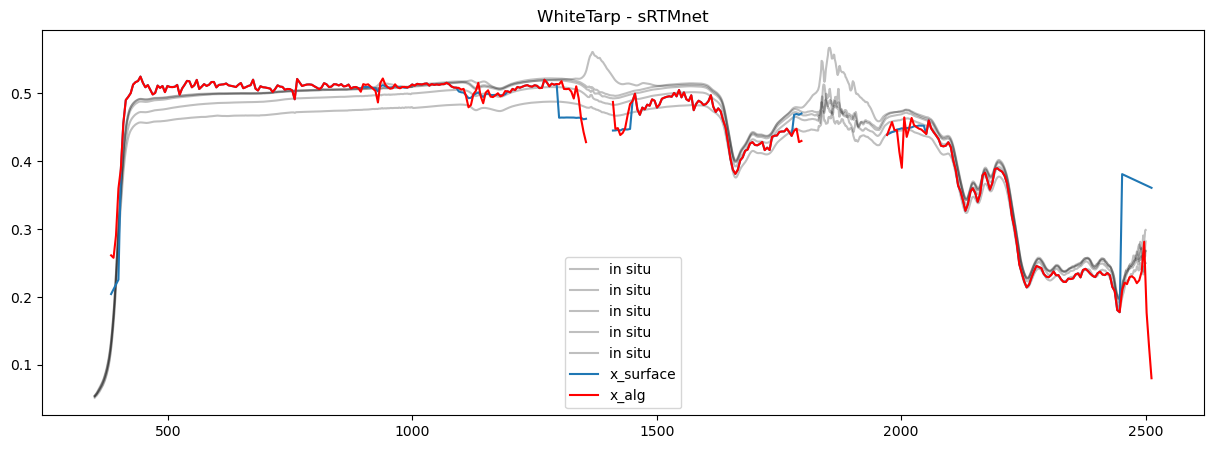

In [6]:
# white tarp, sRTMnet

rte = 'sRTMnet'
k = 'WhiteTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions

# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
plt.plot(wl, x_surface, label='x_surface') # , ls='--'
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_whiteTarp_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 

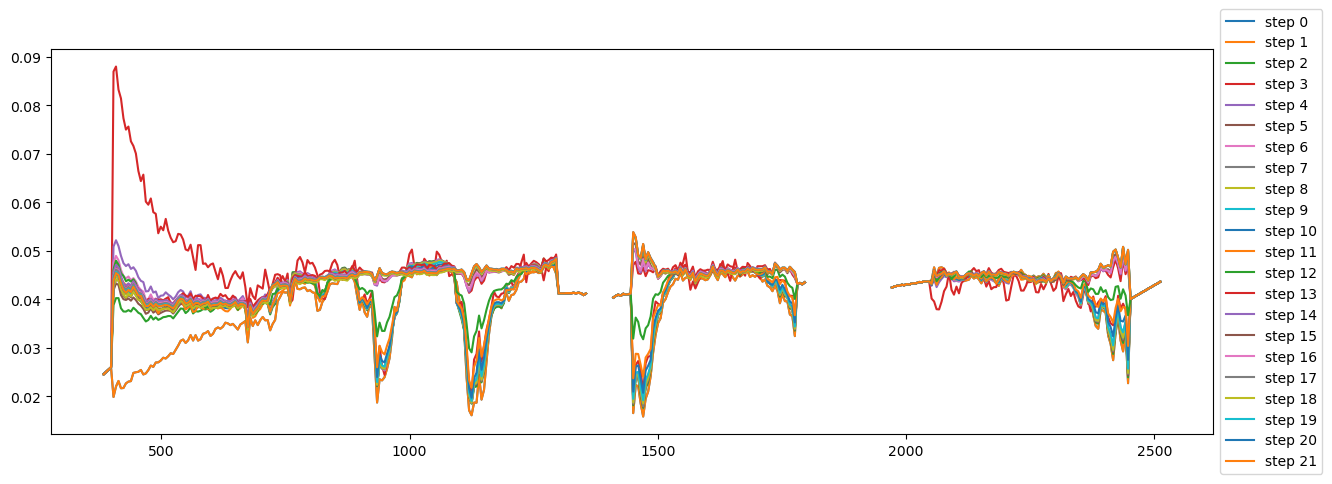

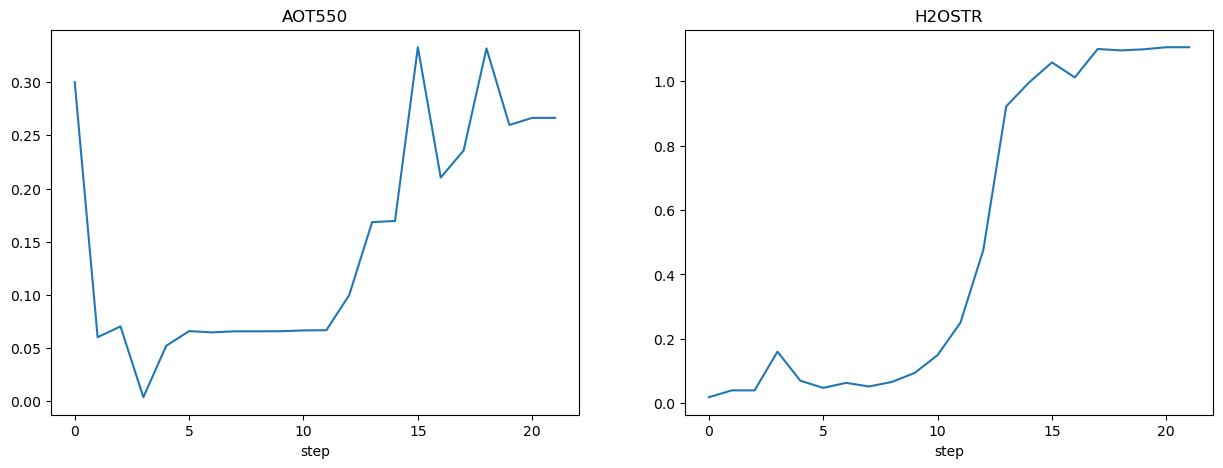

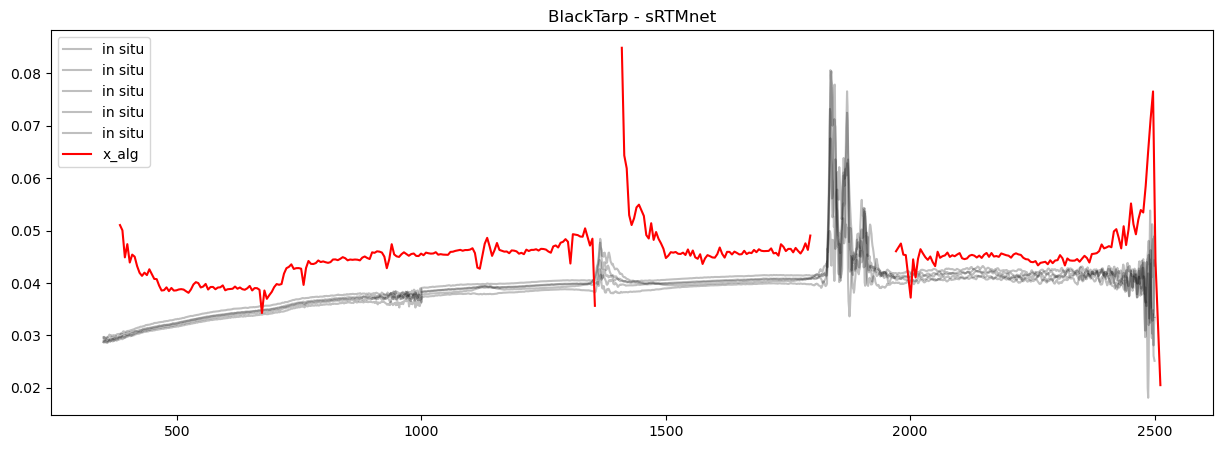

In [7]:
# black tarp, sRTMnet

rte = 'sRTMnet'
k = 'BlackTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
# plt.plot(wl, x_surface, label='x_surface') # , ls='--'
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()


x_alg_blackTarp_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.0001, 0.050098333333333335, 0.10009666666666667, 0.15009499999999998, 0.20009333333333332, 0.25009166666666666, 0.30008999999999997, 0.35

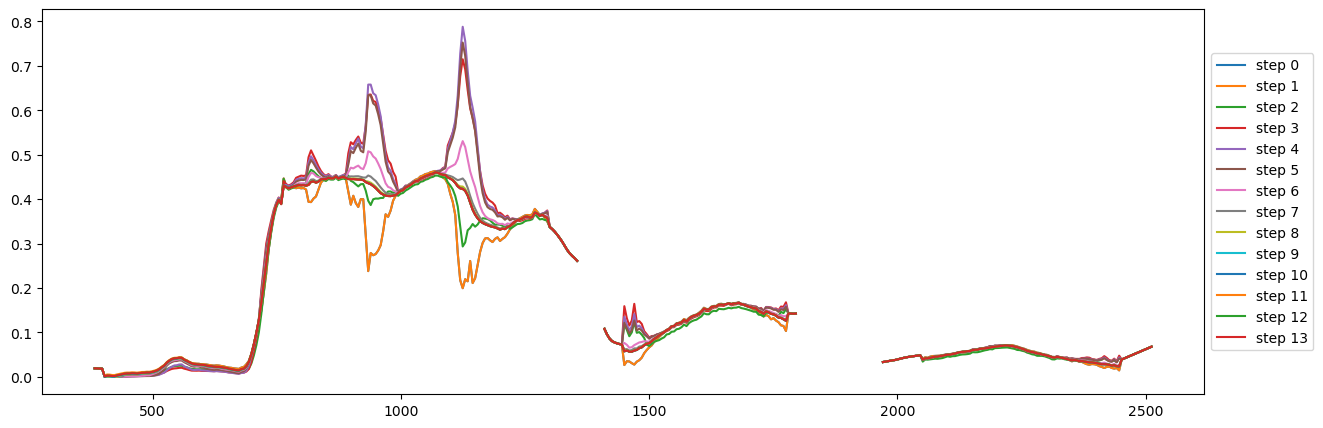

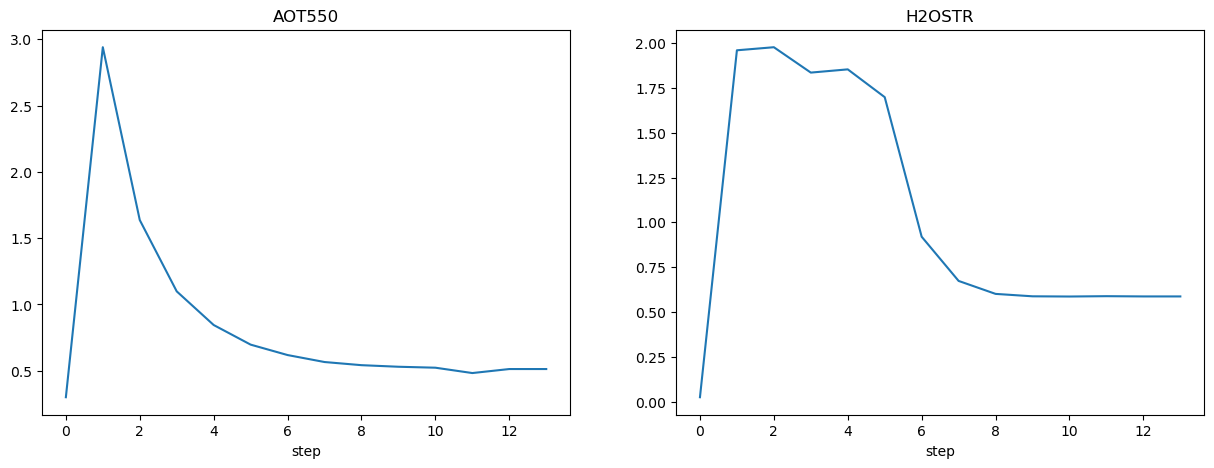

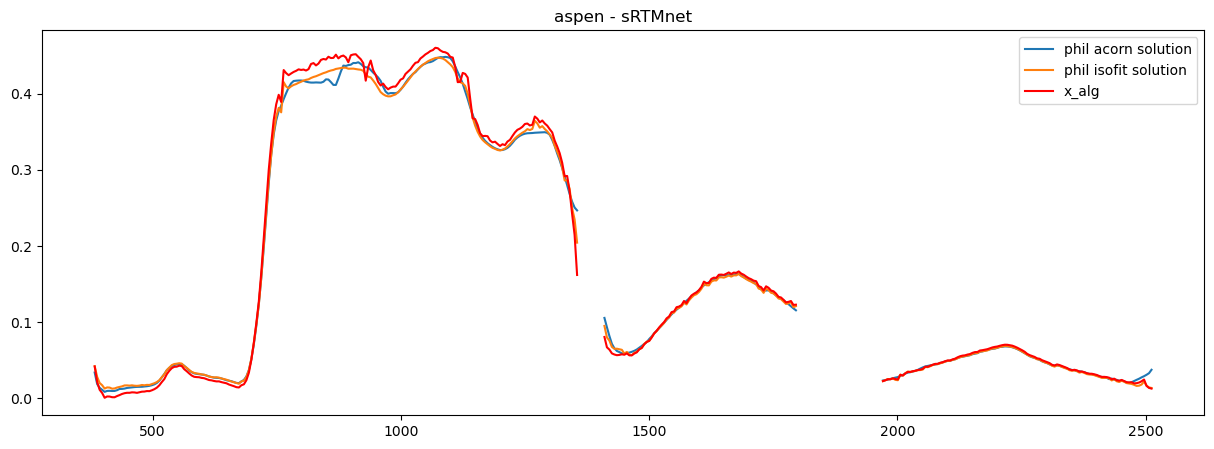

In [8]:
# aspen, srtmnet

rte = 'sRTMnet'
k = 'aspen'
fol = aspen

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions

# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution

# compare w Phil retrievals (original acorn, isofit)
rfl_acorn = envi.open(aspen + '/subset/min_phase_refl.hdr').open_memmap(interleave='bip').copy()/10000
rfl_isofit = envi.open(aspen + 'subset/min_phase_isofit_rfl.hdr').open_memmap(interleave='bip').copy()
rfl_acorn[valid==False,:] = np.nan
rfl_isofit[valid==False,:] = np.nan
rfl_acorn = np.nanmean(rfl_acorn, axis=(0, 1))
rfl_isofit = np.nanmean(rfl_isofit, axis=(0, 1))

fig = plt.figure(figsize=(15,5))
plt.plot(wl, rfl_acorn, label='phil acorn solution')
plt.plot(wl, rfl_isofit, label='phil isofit solution')
# plt.plot(wl, x_surface, label='x_surface')
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_aspen_srtmnet = x_alg.copy()